## Part C - Experiment 1 (Multiclass Version 2 Classification)
-(all features), **5 generes**:-  (***'ambient', 'pop', 'rock', 'sleep', 'piano'***)

In [59]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
import pandas as pd

# Paste your copied raw GitHub URL here
url = 'https://raw.githubusercontent.com/tseringdorjee15/Intro-to-Machine-Learning--2026/refs/heads/main/dataset.csv'          # Github raw dataset link obtained

# Load the dataset directly into a pandas DataFrame from github repository which is "public"
df = pd.read_csv(url)

# Preview the data
df.head()
print(sorted(df['track_genre'].unique()))

['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-rock', 'punk', 'punk-rock', 'r-n-b', 'reggae', 'reggaeton', 'rock',

In [61]:
# Example: selected_genres = ['rock', 'rap', 'jazz', 'latin', 'country', 'pop']
selected_genres = ['ambient', 'pop', 'rock', 'sleep', 'piano']  # <- Enter your genres here

# Filter for the selected genres
df = df[df['track_genre'].isin(selected_genres)]

# Limit the dataset to a sample of 100 tracks per selected genre
df = df.groupby('track_genre').apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)

/tmp/ipykernel_1352/2577425387.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('track_genre').apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)


In [62]:
df['track_genre'].value_counts()
df['track_genre'].unique()

array(['ambient', 'piano', 'pop', 'rock', 'sleep'], dtype=object)

In [63]:
df['track_genre'].value_counts()

,count
track_genre,
ambient,100
piano,100
pop,100
rock,100
sleep,100


## Data Cleaning and Preparation

Preparing data for machine learning involves selecting relevant columns, handling missing values, and encoding categorical variables.
- First, selecting only the most relevant columns focuses the dataset on essential features, simplifying the model and often improving performance.
- Next, handling missing values is crucial because incomplete data can disrupt model training; we address this by either removing rows with missing entries or filling them in with appropriate values, such as the mean or median.
- Finally, encoding categorical variables (like genre) into numerical format allows machine learning algorithms to process non-numeric data. By assigning a unique number to each category using label encoding, we enable the model to interpret these variables accurately, making our dataset ready for analysis.


In [64]:
from sklearn.preprocessing import LabelEncoder        # Imports labelEncoder to encode
# Select relevant columns
df = df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
         'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'explicit', 'track_genre']]

# Drop any rows with missing values
df.dropna(inplace=True)

# Convert 'track_genre' to numerical values (Label Encoding)
label_encoder = LabelEncoder()
df['track_genre'] = label_encoder.fit_transform(df['track_genre'])

# Convert 'explicit' to binary 1/0
df['explicit'] = df['explicit'].astype(int)

# Show class distribution for genres after filtering and sampling
print("\nSampled Genre Distribution:")
print(df['track_genre'].value_counts())


Sampled Genre Distribution:
track_genre
0    100
1    100
2    100
3    100
4    100
Name: count, dtype: int64


## Correlation Analysis

The heatmap above shows correlations between features in the dataset. High correlation values (close to 1 or -1) indicate features that likely carry similar information. Removing one of these correlated features can reduce the dataset’s dimensionality, making the model simpler and potentially improving performance.

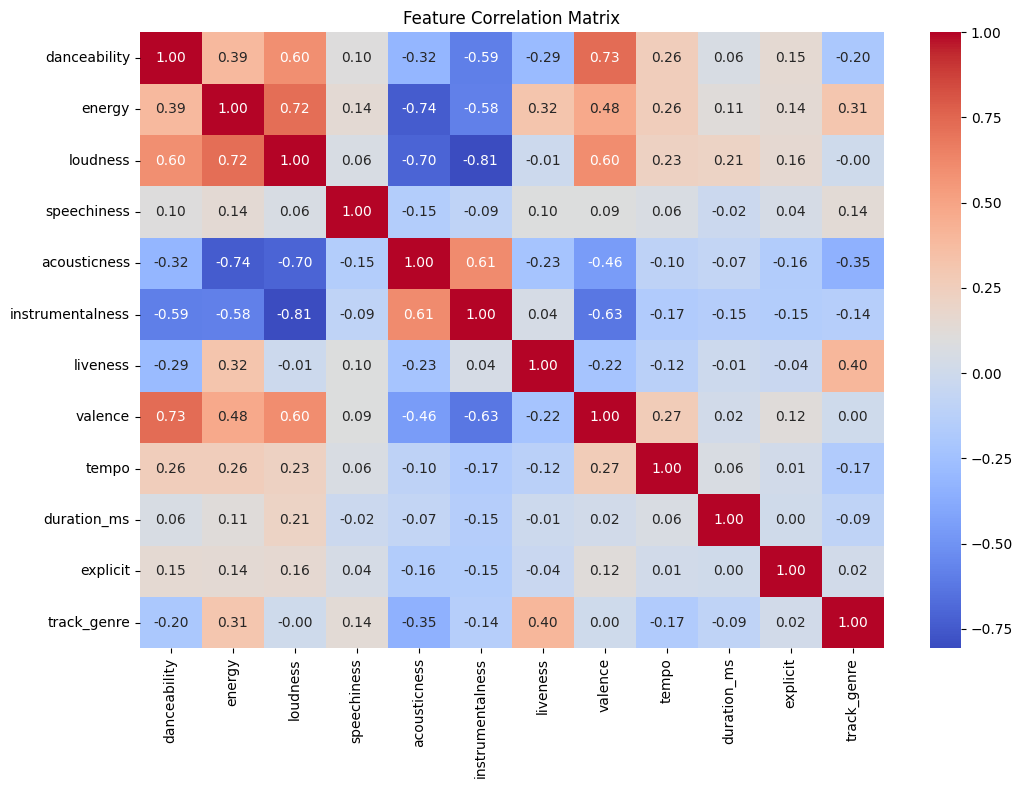

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Heatmap Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## Feature Selection Experiments
**Experiment 1: Train with all features**
Train your models (SVM, KNN, and Random Forest) using all features to establish a baseline. You can do this by running the rest of the notebook without making any changes.

**Experiment 2: Remove one highly correlated feature**
Identify a pair of features with a correlation around |0.7| or higher, then remove one and re-train your models. Note any differences compared to the baseline.

**Experiment 3: Remove multiple correlated features**
Remove multiple features with correlations around |0.7| or higher. Re-train your models and compare these results with both the baseline and Experiment 2.

These experiments will help you understand the impact of correlated features on model performance.

In [66]:
# Example: remove_features = ['danceability', 'liveness', 'speechiness', 'instrumentalness', 'duration_ms']
remove_features = []  # <- Enter  features to remove here   # NONE, WE ARE USING ALL FEATURES

# Drop the selected features
df.drop(columns=remove_features, inplace=True)

## Prepare Data for Modeling

- Split the data into training and testing sets and standardize the features.

In [67]:
# Feature and target selection
X = df.drop(columns=['track_genre'])     # DROPPING TARGET COLUMN "track_genre"
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Train and evaluate three models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. Compare their accuracies to find the best-performing model.

### **1. Support Vector Machine (SVM)**

In [68]:
# 1. Support Vector Machine (SVM)
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.6733333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.51      0.62        39
           1       0.57      0.57      0.57        23
           2       0.55      0.85      0.67        26
           3       0.67      0.58      0.62        31
           4       0.82      0.90      0.86        31

    accuracy                           0.67       150
   macro avg       0.67      0.68      0.67       150
weighted avg       0.69      0.67      0.67       150

Confusion Matrix:
 [[20  8  4  1  6]
 [ 4 13  2  4  0]
 [ 0  0 22  4  0]
 [ 1  0 12 18  0]
 [ 1  2  0  0 28]]


### **2. K-Nearest Neighbors (KNN)**






In [69]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.6133333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.54      0.61        39
           1       0.36      0.57      0.44        23
           2       0.58      0.69      0.63        26
           3       0.57      0.42      0.48        31
           4       0.90      0.87      0.89        31

    accuracy                           0.61       150
   macro avg       0.62      0.62      0.61       150
weighted avg       0.64      0.61      0.62       150

Confusion Matrix:
 [[21 12  2  1  3]
 [ 4 13  1  5  0]
 [ 0  4 18  4  0]
 [ 2  6 10 13  0]
 [ 3  1  0  0 27]]


### **3. Random Forest**

In [70]:
# 3. Random Forest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.64
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.44      0.56        39
           1       0.50      0.78      0.61        23
           2       0.66      0.73      0.69        26
           3       0.62      0.52      0.56        31
           4       0.70      0.84      0.76        31

    accuracy                           0.64       150
   macro avg       0.65      0.66      0.64       150
weighted avg       0.66      0.64      0.63       150

Confusion Matrix:
 [[17 10  0  1 11]
 [ 1 18  0  4  0]
 [ 0  2 19  5  0]
 [ 2  3 10 16  0]
 [ 2  3  0  0 26]]


## Model Comparison

Compare model accuracies to determine the best model for genre classification.

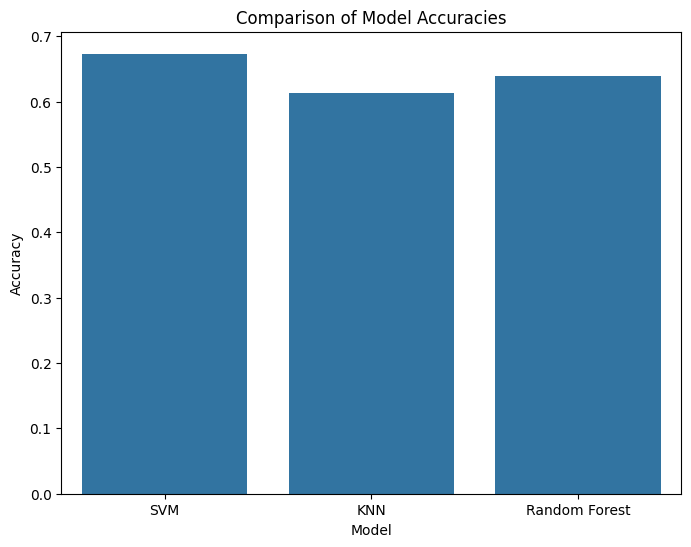

In [71]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

### **NOTE:** Summary **(MODEL COMPARISON)**
- **SVM:** The top-performing model in this run, reaching approximately 67%.
- **RandomFores**t: Placed second at approximately 64%.
- **KNN:** Trailed in third place at approximately 61%.


## Part C - Experiment 1 (Multiclass Version 2 Classification)
--(remove 1 highly corelated feature), **5 generes**:-  (***'ambient', 'pop', 'rock', 'sleep', 'piano'***)

In [72]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.282,0.00212,-36.252,0.0491,0.993,0.964000,0.1040,0.0803,66.720,133629,0,0
1,0.541,0.21000,-22.624,0.0373,0.885,0.868000,0.0876,0.0461,119.916,238318,0,0
2,0.515,0.39000,-9.544,0.0275,0.706,0.000684,0.1370,0.0718,105.981,93400,0,0
3,0.819,0.59900,-6.778,0.0390,0.347,0.824000,0.0830,0.4890,127.986,246506,0,0
4,0.233,0.03580,-28.579,0.0373,0.946,0.878000,0.1080,0.0396,117.497,234000,0,0


In [73]:
df=df.drop(columns='energy')

In [74]:
df.head()            # checking if feature "energy"

,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.282,-36.252,0.0491,0.993,0.964000,0.1040,0.0803,66.720,133629,0,0
1,0.541,-22.624,0.0373,0.885,0.868000,0.0876,0.0461,119.916,238318,0,0
2,0.515,-9.544,0.0275,0.706,0.000684,0.1370,0.0718,105.981,93400,0,0
3,0.819,-6.778,0.0390,0.347,0.824000,0.0830,0.4890,127.986,246506,0,0
4,0.233,-28.579,0.0373,0.946,0.878000,0.1080,0.0396,117.497,234000,0,0


## Prepare Data for Modeling

Split the data into training and testing sets and standardize the features.

In [75]:
# Feature and target selection
X = df.drop(columns=['track_genre'])     # DROPPING TARGET COLUMN "track_genre"
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Train and evaluate three models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. Compare their accuracies to find the best-performing model.

### **1. Support Vector Machine (SVM)**

In [76]:
# 1. Support Vector Machine (SVM)
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.6466666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.41      0.53        39
           1       0.62      0.57      0.59        23
           2       0.52      0.85      0.65        26
           3       0.63      0.55      0.59        31
           4       0.74      0.94      0.83        31

    accuracy                           0.65       150
   macro avg       0.66      0.66      0.64       150
weighted avg       0.67      0.65      0.63       150

Confusion Matrix:
 [[16  6  6  1 10]
 [ 4 13  1  5  0]
 [ 0  0 22  4  0]
 [ 1  0 13 17  0]
 [ 0  2  0  0 29]]


### **2. K-Nearest Neighbors (KNN)**

In [77]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.6133333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.54      0.61        39
           1       0.41      0.57      0.47        23
           2       0.59      0.73      0.66        26
           3       0.50      0.39      0.44        31
           4       0.84      0.87      0.86        31

    accuracy                           0.61       150
   macro avg       0.61      0.62      0.61       150
weighted avg       0.62      0.61      0.61       150

Confusion Matrix:
 [[21 10  1  2  5]
 [ 4 13  1  5  0]
 [ 1  1 19  5  0]
 [ 2  6 11 12  0]
 [ 2  2  0  0 27]]


### **3. Random Forest**

In [78]:
# 3. Random Forest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.6
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.38      0.51        39
           1       0.41      0.74      0.53        23
           2       0.55      0.62      0.58        26
           3       0.60      0.48      0.54        31
           4       0.77      0.87      0.82        31

    accuracy                           0.60       150
   macro avg       0.62      0.62      0.60       150
weighted avg       0.64      0.60      0.59       150

Confusion Matrix:
 [[15 13  2  1  8]
 [ 2 17  1  3  0]
 [ 1  3 16  6  0]
 [ 2  4 10 15  0]
 [ 0  4  0  0 27]]


# Model Comparison

Compare model accuracies to determine the best model for genre classification.

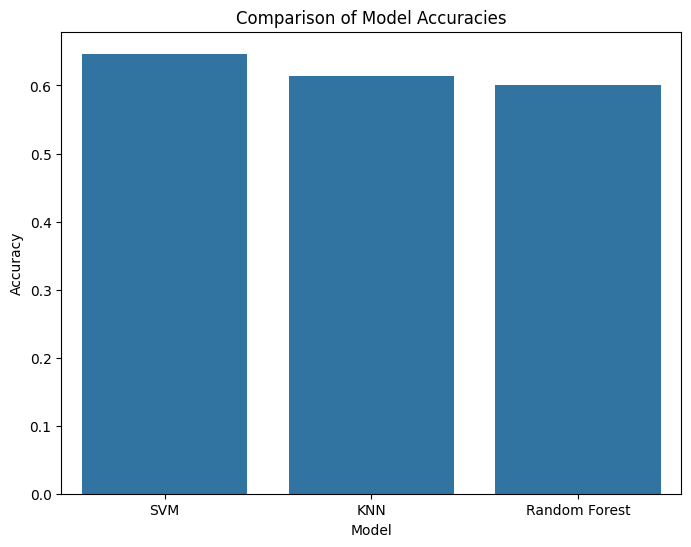

In [79]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

## SUMMARY MODEL PERFORMANCE COMPARISON:

- **SVM:** The top-performing model, hitting approximately 64%.
- **KNN:** Placed second at approximately 61%.
- **Random Forest**: Trailed in third place at approximately 60%.

## Part C - Experiment 3 (Multiclass Version 2 Classification)
-(remove more than 1 corelated feature), **5 generes**:-  (***'ambient', 'pop', 'rock', 'sleep', 'piano'***)

In [80]:
df.head()

,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.282,-36.252,0.0491,0.993,0.964000,0.1040,0.0803,66.720,133629,0,0
1,0.541,-22.624,0.0373,0.885,0.868000,0.0876,0.0461,119.916,238318,0,0
2,0.515,-9.544,0.0275,0.706,0.000684,0.1370,0.0718,105.981,93400,0,0
3,0.819,-6.778,0.0390,0.347,0.824000,0.0830,0.4890,127.986,246506,0,0
4,0.233,-28.579,0.0373,0.946,0.878000,0.1080,0.0396,117.497,234000,0,0


In [81]:

df = df.drop(columns=['loudness', 'instrumentalness'])


In [82]:
df.head()

,danceability,speechiness,acousticness,liveness,valence,tempo,duration_ms,explicit,track_genre
0,0.282,0.0491,0.993,0.1040,0.0803,66.720,133629,0,0
1,0.541,0.0373,0.885,0.0876,0.0461,119.916,238318,0,0
2,0.515,0.0275,0.706,0.1370,0.0718,105.981,93400,0,0
3,0.819,0.0390,0.347,0.0830,0.4890,127.986,246506,0,0
4,0.233,0.0373,0.946,0.1080,0.0396,117.497,234000,0,0


## Prepare Data for Modeling

Split the data into training and testing sets and standardize the features.

In [83]:
# Feature and target selection
X = df.drop(columns=['track_genre'])     # DROPPING TARGET COLUMN "track_genre"
y = df['track_genre']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Evaluation

Train and evaluate three models: Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Random Forest. Compare their accuracies to find the best-performing model.

### **1. Support Vector Machine (SVM)**

In [84]:
# 1. Support Vector Machine (SVM)
print("\nSupport Vector Machine (SVM) Results:")
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Support Vector Machine (SVM) Results:
SVM Accuracy: 0.6066666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.38      0.48        39
           1       0.46      0.52      0.49        23
           2       0.59      0.77      0.67        26
           3       0.62      0.58      0.60        31
           4       0.70      0.84      0.76        31

    accuracy                           0.61       150
   macro avg       0.60      0.62      0.60       150
weighted avg       0.61      0.61      0.60       150

Confusion Matrix:
 [[15 10  1  2 11]
 [ 5 12  1  5  0]
 [ 1  1 20  4  0]
 [ 0  1 12 18  0]
 [ 3  2  0  0 26]]


### **2. K-Nearest Neighbors (KNN)**

In [85]:
# 2. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.5666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.51      0.57        39
           1       0.33      0.43      0.38        23
           2       0.51      0.69      0.59        26
           3       0.48      0.35      0.41        31
           4       0.84      0.84      0.84        31

    accuracy                           0.57       150
   macro avg       0.56      0.57      0.56       150
weighted avg       0.58      0.57      0.57       150

Confusion Matrix:
 [[20 10  2  2  5]
 [ 7 10  1  5  0]
 [ 1  2 18  5  0]
 [ 1  5 14 11  0]
 [ 2  3  0  0 26]]


### **3. Random Forest**

In [86]:
# 3. Random Forest
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results:
Random Forest Accuracy: 0.62
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.38      0.50        39
           1       0.50      0.78      0.61        23
           2       0.58      0.69      0.63        26
           3       0.62      0.52      0.56        31
           4       0.72      0.84      0.78        31

    accuracy                           0.62       150
   macro avg       0.63      0.64      0.62       150
weighted avg       0.64      0.62      0.61       150

Confusion Matrix:
 [[15 11  0  3 10]
 [ 1 18  2  2  0]
 [ 1  2 18  5  0]
 [ 1  3 11 16  0]
 [ 3  2  0  0 26]]


# Model Comparison

Compare model accuracies to determine the best model for genre classification.

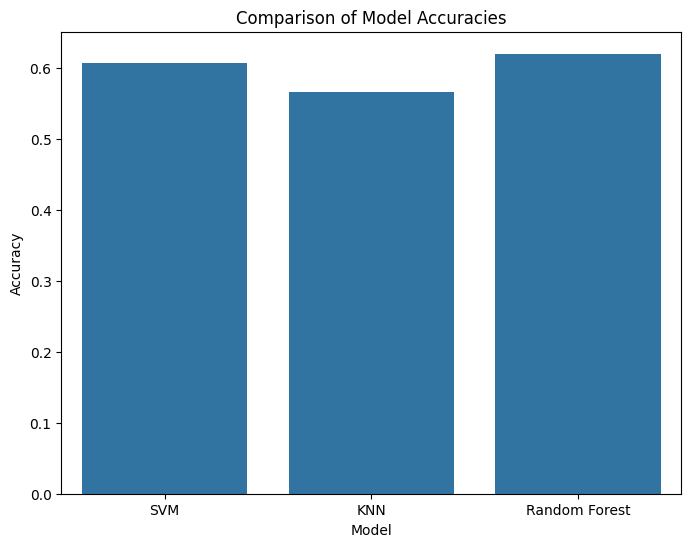

In [87]:
# Comparison of Model Accuracies
model_names = ['SVM', 'KNN', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

### SUMMARY: (**MODEL COMPARISON**)
- **Random Forest:** The top-performing model, hitting approximately 62%.
- **SVM:** Placed second close behind at approximately 60.5%.
- **KNN:** Trailed in third place at approximately 56.5%

**# OVERALL RESULT SUMMARY:**
- **SVM:** performs best when using all features for 5 genres (0.67) and when evaluating 3 genres (0.72), but drops to 0.61 when multiple features are removed.
- **KNN:** struggles consistently across the board, hitting its lowest accuracy score of 0.57 in the final 5-genre feature removal experiment.
- **Random Forest:** remains the most stable model overall, maintaining a steady score of 0.63 to 0.64 regardless of the genre count or feature modifications.



| Model | Part C - Exp 1 (5 Genres) | Part B - Exp 2 (3 Genres) | Part C - Exp 3 (5 Genres) |
| :--- | :---: | :---: | :---: |
| **SVM** | 0.67 | 0.72 | 0.61 |
| **KNN** | 0.61 | 0.61 | 0.57 |
| **Random Forest** | 0.63 | 0.64 | 0.63 |
